## 1. Data Preprocessing

In [ ]:
# ============================================================
# Imports and dataset loading
# ============================================================
# IMPORTANT:
# sklearn is used ONLY to load the dataset required by the assignment.
# No sklearn model, scaler, optimizer, train_test_split, or neural
# network function is used anywhere in the implementation.

from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Load the required California Housing dataset
housing = fetch_california_housing()

X_all = housing.data
y_all = housing.target.reshape(-1, 1)

print("Full dataset shape:", X_all.shape)
print("Target shape:", y_all.shape)
print("All feature names:", housing.feature_names)

# Required features:
# MedInc   -> column 0
# HouseAge -> column 1
#
# The assignment asks us to use only these two features.
feature_indices = [0, 1]

X_selected = X_all[:, feature_indices]

print("\nSelected features:")
print("1. MedInc")
print("2. HouseAge")
print("Selected feature shape:", X_selected.shape)
print("Target: MedHouseVal")


Full dataset shape: (20640, 8)
Target shape: (20640, 1)
All feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Selected features:
1. MedInc
2. HouseAge
Selected feature shape: (20640, 2)
Target: MedHouseVal


### Normalize the features

In [ ]:
# ============================================================
# Manual feature normalization
# ============================================================
# We first split the data and then calculate the mean/std ONLY
# from the training set. This avoids test-set data leakage.

np.random.seed(SEED)

n_samples = X_selected.shape[0]
indices = np.random.permutation(n_samples)

train_size = int(0.80 * n_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train_raw = X_selected[train_indices]
X_test_raw = X_selected[test_indices]

y_train = y_all[train_indices]
y_test = y_all[test_indices]

# Manual standardization:
# x_normalized = (x - mean) / std

X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0)

# Safety check in case a feature has zero variance
X_std = np.where(X_std == 0, 1.0, X_std)

X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature mean:")
print(np.mean(X_train, axis=0))

print("\nTraining feature standard deviation:")
print(np.std(X_train, axis=0))

print("\nFirst 5 normalized training rows:")
print(X_train[:5])


Training samples: 16512
Testing samples: 4128

Training feature mean:
[-9.81836846e-15 -6.79904023e-17]

Training feature standard deviation:
[1. 1.]

First 5 normalized training rows:
[[-1.15453971 -0.29052552]
 [-0.7062249   0.10661646]
 [-0.20585896  1.85404119]
 [ 0.98467237 -0.9259527 ]
 [-0.07670674  0.42433005]]


### Split the dataset into training and test sets

In [ ]:
# ============================================================
# Verify the manual 80/20 train-test split
# ============================================================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nTraining percentage:",
      100 * len(X_train) / len(X_selected), "%")

print("Testing percentage :",
      100 * len(X_test) / len(X_selected), "%")


X_train shape: (16512, 2)
y_train shape: (16512, 1)
X_test shape : (4128, 2)
y_test shape : (4128, 1)

Training percentage: 80.0 %
Testing percentage : 20.0 %


## 2. Model Implementation (Neural Network from Scratch)

### Define Activation Functions

In [ ]:
class ReLU:
    def forward(self, x):
        self.input = x
        return np.maximum(0, x)

    def backward(self, grad_output):
        grad_input = grad_output * (self.input > 0)
        return grad_input

class Linear:
    def forward(self, x):
        self.input = x
        return x

    def backward(self, grad_output):
        # For a linear activation (y=x), the derivative is 1
        return grad_output


### Implement a `Layer` class

In [ ]:
# ============================================================
# Dense layer implemented from scratch
# ============================================================

class DenseLayer:
    """
    Fully connected layer implemented using NumPy only.

    Forward:
        Z = XW + b

    Backward:
        dW = X^T dZ
        db = sum(dZ)
        dX = dZ W^T
    """

    def __init__(self, input_size, output_size, activation=None, seed=None):
        if seed is not None:
            np.random.seed(seed)

        self.activation = activation

        # He initialization is appropriate for ReLU hidden layers.
        if activation == "relu":
            self.weights = (
                np.random.randn(input_size, output_size)
                * np.sqrt(2.0 / input_size)
            )
        else:
            # Small initialization for the linear output layer.
            self.weights = (
                np.random.randn(input_size, output_size)
                * np.sqrt(1.0 / input_size)
            )

        self.biases = np.zeros((1, output_size))

        # Values saved during forward propagation
        self.input = None
        self.z = None
        self.output = None

        # Gradients
        self.grad_weights = np.zeros_like(self.weights)
        self.grad_biases = np.zeros_like(self.biases)

    def forward(self, X):
        self.input = X
        self.z = X @ self.weights + self.biases

        if self.activation == "relu":
            self.output = np.maximum(0.0, self.z)
        elif self.activation == "linear":
            self.output = self.z
        else:
            self.output = self.z

        return self.output

    def backward(self, grad_output):
        # Derivative of activation
        if self.activation == "relu":
            grad_z = grad_output * (self.z > 0)
        else:
            # Linear activation derivative = 1
            grad_z = grad_output

        # Parameter gradients
        self.grad_weights = self.input.T @ grad_z
        self.grad_biases = np.sum(grad_z, axis=0, keepdims=True)

        # Gradient passed to the previous layer
        grad_input = grad_z @ self.weights.T

        return grad_input


### Implement the `NeuralNetwork` class

In [ ]:
# ============================================================
# Neural Network implemented from scratch
# ============================================================

class NeuralNetwork:
    """
    Neural network architecture is defined by a list such as:

        [(5, "relu"), (3, "relu")]

    which creates:

        input -> 5 ReLU -> 3 ReLU -> 1 Linear

    All forward propagation and backpropagation operations
    are implemented manually with NumPy.
    """

    def __init__(self, input_size, hidden_layers_config, output_size, seed=42):
        self.layers = []

        current_size = input_size

        # Create hidden layers
        for layer_number, (neurons, activation) in enumerate(
            hidden_layers_config
        ):
            layer_seed = seed + layer_number
            self.layers.append(
                DenseLayer(
                    current_size,
                    neurons,
                    activation=activation,
                    seed=layer_seed
                )
            )
            current_size = neurons

        # Required regression output layer:
        # one neuron + linear activation
        self.layers.append(
            DenseLayer(
                current_size,
                output_size,
                activation="linear",
                seed=seed + len(hidden_layers_config)
            )
        )

    def forward(self, X):
        output = X

        for layer in self.layers:
            output = layer.forward(output)

        return output

    def backward(self, grad_output):
        """
        Backpropagate through all layers in reverse order.
        """
        gradient = grad_output

        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)

    def get_parameters(self):
        return [
            (layer.weights, layer.biases)
            for layer in self.layers
        ]

    def predict(self, X):
        return self.forward(X)


## 3. Training the Network

### Define Network Architecture and Training Parameters

In [ ]:
# ============================================================
# Required network architecture and training parameters
# ============================================================

input_size = 2

hidden_layers_config = [
    (5, "relu"),   # First hidden layer: 5 neurons + ReLU
    (3, "relu")    # Second hidden layer: 3 neurons + ReLU
]

output_size = 1    # Regression output: MedHouseVal

epochs = 1000

print("Network architecture:")
print("Input Layer       : 2 neurons")
print("Hidden Layer 1    : 5 neurons + ReLU")
print("Hidden Layer 2    : 3 neurons + ReLU")
print("Output Layer      : 1 neuron + Linear")
print("\nArchitecture: 2 -> 5 -> 3 -> 1")
print("Epochs:", epochs)


Network architecture:
Input Layer       : 2 neurons
Hidden Layer 1    : 5 neurons + ReLU
Hidden Layer 2    : 3 neurons + ReLU
Output Layer      : 1 neuron + Linear

Architecture: 2 -> 5 -> 3 -> 1
Epochs: 1000


### Experiment with different learning rates (Basic Gradient Descent)


Basic Gradient Descent | Learning Rate = 0.01
Epoch    1/1000 | Training MSE = 3.014886
Epoch  100/1000 | Training MSE = 0.689151
Epoch  200/1000 | Training MSE = 0.657615
Epoch  300/1000 | Training MSE = 0.648658
Epoch  400/1000 | Training MSE = 0.643154
Epoch  500/1000 | Training MSE = 0.639882
Epoch  600/1000 | Training MSE = 0.637845
Epoch  700/1000 | Training MSE = 0.636607
Epoch  800/1000 | Training MSE = 0.635776
Epoch  900/1000 | Training MSE = 0.635214
Epoch 1000/1000 | Training MSE = 0.634849

Basic Gradient Descent | Learning Rate = 0.001
Epoch    1/1000 | Training MSE = 3.014886
Epoch  100/1000 | Training MSE = 1.738311
Epoch  200/1000 | Training MSE = 1.293374
Epoch  300/1000 | Training MSE = 1.058341
Epoch  400/1000 | Training MSE = 0.917815
Epoch  500/1000 | Training MSE = 0.830625
Epoch  600/1000 | Training MSE = 0.775172
Epoch  700/1000 | Training MSE = 0.739364
Epoch  800/1000 | Training MSE = 0.715635
Epoch  900/1000 | Training MSE = 0.699619
Epoch 1000/1000 | Train

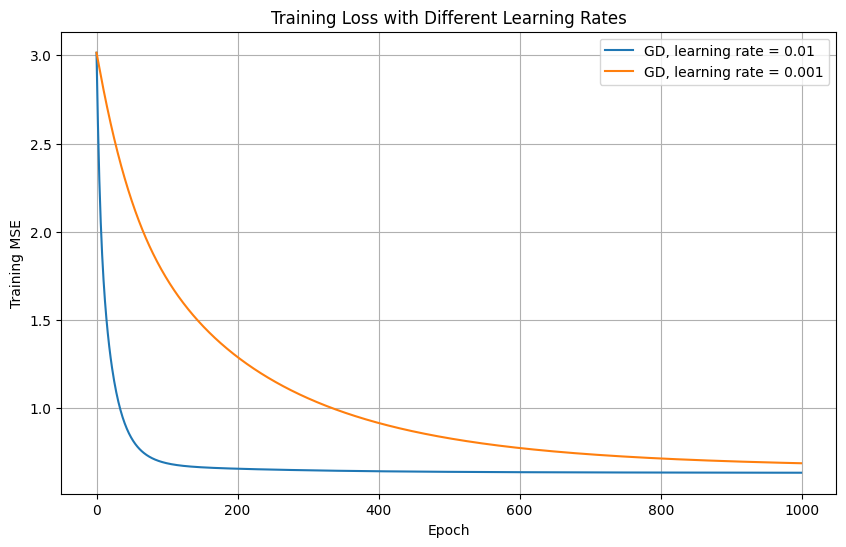

In [ ]:
# ============================================================
# Loss, gradient clipping, and Basic Gradient Descent
# ============================================================

def mse_loss(y_true, y_pred):
    """Mean Squared Error implemented from scratch."""
    return np.mean((y_true - y_pred) ** 2)


def mse_gradient(y_true, y_pred):
    """Derivative of MSE with respect to predictions."""
    n = y_true.shape[0]
    return (2.0 / n) * (y_pred - y_true)


def clip_gradients(model, max_norm=5.0):
    """
    Optional numerical-stability safeguard.
    This does NOT replace the optimizer.
    """
    total_squared_norm = 0.0

    for layer in model.layers:
        total_squared_norm += np.sum(layer.grad_weights ** 2)
        total_squared_norm += np.sum(layer.grad_biases ** 2)

    total_norm = np.sqrt(total_squared_norm)

    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-12)

        for layer in model.layers:
            layer.grad_weights *= scale
            layer.grad_biases *= scale


def train_basic_gd(
    model,
    X,
    y,
    epochs,
    learning_rate,
    gradient_clip_norm=5.0
):
    """Full-batch Gradient Descent implemented from scratch."""

    history = []

    for epoch in range(1, epochs + 1):

        # Forward pass
        predictions = model.forward(X)

        # Loss
        loss = mse_loss(y, predictions)
        history.append(loss)

        # Backward pass
        grad_output = mse_gradient(y, predictions)
        model.backward(grad_output)

        # Optional clipping
        if gradient_clip_norm is not None:
            clip_gradients(model, gradient_clip_norm)

        # Gradient Descent update
        for layer in model.layers:
            layer.weights -= learning_rate * layer.grad_weights
            layer.biases -= learning_rate * layer.grad_biases

        if epoch == 1 or epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"Training MSE = {loss:.6f}"
            )

    return history


# ------------------------------------------------------------
# Experiment: Basic Gradient Descent with two learning rates
# ------------------------------------------------------------

learning_rates = [0.01, 0.001]
training_histories = {}
gd_models = {}

for lr in learning_rates:

    print("\n" + "=" * 60)
    print(f"Basic Gradient Descent | Learning Rate = {lr}")
    print("=" * 60)

    model = NeuralNetwork(
        input_size=input_size,
        hidden_layers_config=hidden_layers_config,
        output_size=output_size,
        seed=SEED
    )

    history = train_basic_gd(
        model,
        X_train,
        y_train,
        epochs=epochs,
        learning_rate=lr
    )

    training_histories[lr] = history
    gd_models[lr] = model


# Plot convergence
plt.figure(figsize=(10, 6))

for lr, history in training_histories.items():
    plt.plot(
        history,
        label=f"GD, learning rate = {lr}"
    )

plt.title("Training Loss with Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.legend()
plt.grid(True)
plt.show()


_Visualization generated by the preceding code cell._


### Experiment with different optimizers


Optimizer: GD | Learning Rate = 0.001
Epoch    1/1000 | Training MSE = 3.014886
Epoch  100/1000 | Training MSE = 1.738311
Epoch  200/1000 | Training MSE = 1.293374
Epoch  300/1000 | Training MSE = 1.058341
Epoch  400/1000 | Training MSE = 0.917815
Epoch  500/1000 | Training MSE = 0.830625
Epoch  600/1000 | Training MSE = 0.775172
Epoch  700/1000 | Training MSE = 0.739364
Epoch  800/1000 | Training MSE = 0.715635
Epoch  900/1000 | Training MSE = 0.699619
Epoch 1000/1000 | Training MSE = 0.688571

Optimizer: MOMENTUM | Learning Rate = 0.001
Epoch    1/1000 | Training MSE = 1.598282
Epoch  100/1000 | Training MSE = 0.634119
Epoch  200/1000 | Training MSE = 0.632114
Epoch  300/1000 | Training MSE = 0.629651
Epoch  400/1000 | Training MSE = 0.622387
Epoch  500/1000 | Training MSE = 0.617865
Epoch  600/1000 | Training MSE = 0.614539
Epoch  700/1000 | Training MSE = 0.612039
Epoch  800/1000 | Training MSE = 0.610169
Epoch  900/1000 | Training MSE = 0.608623
Epoch 1000/1000 | Training MSE = 0

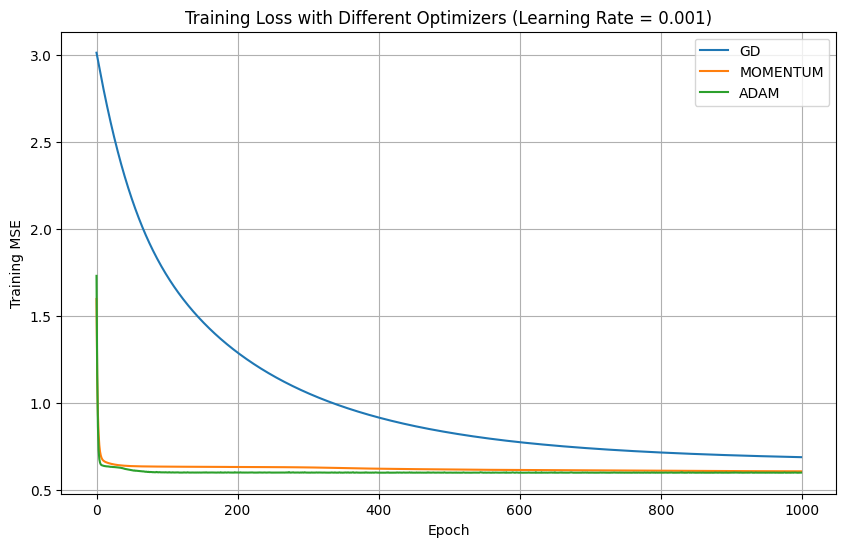

In [ ]:
# ============================================================
# SGD with Momentum and Adam implemented from scratch
# ============================================================
#
# For a fair optimizer comparison:
# - Same architecture
# - Same initialization
# - Same number of epochs
# - Same learning rate
#
# Momentum and Adam use mini-batch SGD.
# ============================================================

def create_optimizer_state(model):
    """
    Create zero-valued optimizer state for every layer.
    """
    state = []

    for layer in model.layers:
        state.append({
            "v_w": np.zeros_like(layer.weights),
            "v_b": np.zeros_like(layer.biases),
            "m_w": np.zeros_like(layer.weights),
            "m_b": np.zeros_like(layer.biases),
            "s_w": np.zeros_like(layer.weights),
            "s_b": np.zeros_like(layer.biases),
        })

    return state


def train_momentum(
    model,
    X,
    y,
    epochs,
    learning_rate=0.001,
    beta=0.9,
    batch_size=128,
    gradient_clip_norm=5.0,
    seed=42
):
    """
    Mini-batch SGD with Momentum.
    """

    rng = np.random.default_rng(seed)
    state = create_optimizer_state(model)
    history = []

    n = X.shape[0]

    for epoch in range(1, epochs + 1):

        order = rng.permutation(n)

        for start in range(0, n, batch_size):

            batch_indices = order[start:start + batch_size]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # Forward
            predictions = model.forward(X_batch)

            # Backward
            grad_output = mse_gradient(y_batch, predictions)
            model.backward(grad_output)

            if gradient_clip_norm is not None:
                clip_gradients(model, gradient_clip_norm)

            # Momentum update
            for layer, layer_state in zip(model.layers, state):

                layer_state["v_w"] = (
                    beta * layer_state["v_w"]
                    + (1 - beta) * layer.grad_weights
                )

                layer_state["v_b"] = (
                    beta * layer_state["v_b"]
                    + (1 - beta) * layer.grad_biases
                )

                layer.weights -= learning_rate * layer_state["v_w"]
                layer.biases -= learning_rate * layer_state["v_b"]

        # Full training-set loss after the epoch
        full_predictions = model.forward(X)
        epoch_loss = mse_loss(y, full_predictions)
        history.append(epoch_loss)

        if epoch == 1 or epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"Training MSE = {epoch_loss:.6f}"
            )

    return history


def train_adam(
    model,
    X,
    y,
    epochs,
    learning_rate=0.001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    batch_size=128,
    gradient_clip_norm=5.0,
    seed=42
):
    """
    Mini-batch Adam implemented from scratch.

    Adam steps:
        1. First moment
        2. Second moment
        3. Bias correction
        4. Parameter update
    """

    rng = np.random.default_rng(seed)
    state = create_optimizer_state(model)
    history = []

    n = X.shape[0]

    for epoch in range(1, epochs + 1):

        order = rng.permutation(n)

        for start in range(0, n, batch_size):

            batch_indices = order[start:start + batch_size]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # Forward
            predictions = model.forward(X_batch)

            # Backward
            grad_output = mse_gradient(y_batch, predictions)
            model.backward(grad_output)

            if gradient_clip_norm is not None:
                clip_gradients(model, gradient_clip_norm)

            # Adam update
            for layer, layer_state in zip(model.layers, state):

                layer_state["m_w"] = (
                    beta1 * layer_state["m_w"]
                    + (1 - beta1) * layer.grad_weights
                )

                layer_state["m_b"] = (
                    beta1 * layer_state["m_b"]
                    + (1 - beta1) * layer.grad_biases
                )

                layer_state["s_w"] = (
                    beta2 * layer_state["s_w"]
                    + (1 - beta2) * (layer.grad_weights ** 2)
                )

                layer_state["s_b"] = (
                    beta2 * layer_state["s_b"]
                    + (1 - beta2) * (layer.grad_biases ** 2)
                )

                # Bias correction uses the mini-batch update step.
                # We use a monotonically increasing global step.
                if "step" not in layer_state:
                    layer_state["step"] = 0

                layer_state["step"] += 1
                t = layer_state["step"]

                m_w_hat = layer_state["m_w"] / (1 - beta1 ** t)
                m_b_hat = layer_state["m_b"] / (1 - beta1 ** t)

                s_w_hat = layer_state["s_w"] / (1 - beta2 ** t)
                s_b_hat = layer_state["s_b"] / (1 - beta2 ** t)

                layer.weights -= (
                    learning_rate
                    * m_w_hat
                    / (np.sqrt(s_w_hat) + epsilon)
                )

                layer.biases -= (
                    learning_rate
                    * m_b_hat
                    / (np.sqrt(s_b_hat) + epsilon)
                )

        # Full training-set loss after the epoch
        full_predictions = model.forward(X)
        epoch_loss = mse_loss(y, full_predictions)
        history.append(epoch_loss)

        if epoch == 1 or epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"Training MSE = {epoch_loss:.6f}"
            )

    return history


# ------------------------------------------------------------
# Compare optimizers at learning rate = 0.001
# ------------------------------------------------------------

optimizers = ["gd", "momentum", "adam"]
fixed_learning_rate = 0.001

optimizer_histories = {}
optimizer_models = {}

for opt_name in optimizers:

    print("\n" + "=" * 60)
    print(
        f"Optimizer: {opt_name.upper()} | "
        f"Learning Rate = {fixed_learning_rate}"
    )
    print("=" * 60)

    model = NeuralNetwork(
        input_size=input_size,
        hidden_layers_config=hidden_layers_config,
        output_size=output_size,
        seed=SEED
    )

    if opt_name == "gd":

        history = train_basic_gd(
            model,
            X_train,
            y_train,
            epochs=epochs,
            learning_rate=fixed_learning_rate
        )

    elif opt_name == "momentum":

        history = train_momentum(
            model,
            X_train,
            y_train,
            epochs=epochs,
            learning_rate=fixed_learning_rate,
            beta=0.9,
            batch_size=128,
            seed=SEED
        )

    elif opt_name == "adam":

        history = train_adam(
            model,
            X_train,
            y_train,
            epochs=epochs,
            learning_rate=fixed_learning_rate,
            beta1=0.9,
            beta2=0.999,
            epsilon=1e-8,
            batch_size=128,
            seed=SEED
        )

    optimizer_histories[opt_name] = history
    optimizer_models[opt_name] = model


# Plot optimizer convergence
plt.figure(figsize=(10, 6))

for opt_name, history in optimizer_histories.items():
    plt.plot(
        history,
        label=opt_name.upper()
    )

plt.title(
    f"Training Loss with Different Optimizers "
    f"(Learning Rate = {fixed_learning_rate})"
)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.legend()
plt.grid(True)
plt.show()


_Visualization generated by the preceding code cell._


## 4. Evaluation

### Evaluate the trained model on the test set and calculate MSE

In [ ]:
# ============================================================
# Evaluate the trained models on the test set
# ============================================================

test_results = {}

for opt_name, model in optimizer_models.items():

    predictions = model.predict(X_test)
    test_mse = mse_loss(y_test, predictions)

    train_predictions = model.predict(X_train)
    train_mse = mse_loss(y_train, train_predictions)

    test_results[opt_name] = {
        "train_mse": train_mse,
        "test_mse": test_mse,
        "predictions": predictions
    }

    print(
        f"{opt_name.upper():10s} | "
        f"Train MSE = {train_mse:.6f} | "
        f"Test MSE = {test_mse:.6f}"
    )

# Find the best optimizer according to test MSE
best_optimizer = min(
    test_results,
    key=lambda name: test_results[name]["test_mse"]
)

best_nn = optimizer_models[best_optimizer]
y_pred = test_results[best_optimizer]["predictions"]

mse = test_results[best_optimizer]["test_mse"]

print("\nBest optimizer:", best_optimizer.upper())
print("Best test MSE:", mse)


GD         | Train MSE = 0.688480 | Test MSE = 0.710231
MOMENTUM   | Train MSE = 0.607227 | Test MSE = 0.630170
ADAM       | Train MSE = 0.599846 | Test MSE = 0.621427

Best optimizer: ADAM
Best test MSE: 0.6214272139540666


### Visualize the regression results

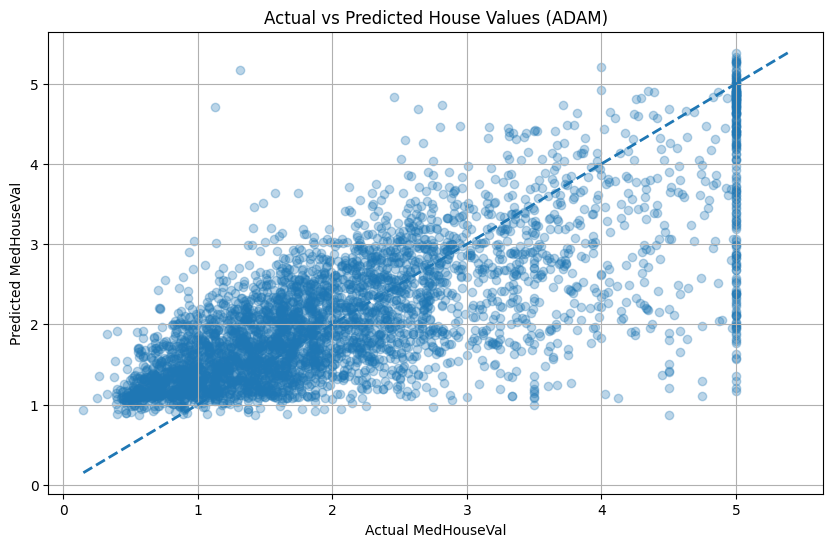

In [ ]:
# ============================================================
# Actual vs Predicted Median House Values
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test.ravel(),
    y_pred.ravel(),
    alpha=0.3
)

# Ideal prediction line: y = x
minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title(
    f"Actual vs Predicted House Values "
    f"({best_optimizer.upper()})"
)

plt.grid(True)
plt.show()


_Visualization generated by the preceding code cell._


## 5. Bonus Questions

### 5.1. Additional Hidden Layers


BONUS: 3-HIDDEN-LAYER NETWORK
Epoch    1/1000 | Training MSE = 3.728264
Epoch  100/1000 | Training MSE = 0.602087
Epoch  200/1000 | Training MSE = 0.600996
Epoch  300/1000 | Training MSE = 0.601165
Epoch  400/1000 | Training MSE = 0.600454
Epoch  500/1000 | Training MSE = 0.600565
Epoch  600/1000 | Training MSE = 0.600344
Epoch  700/1000 | Training MSE = 0.600915
Epoch  800/1000 | Training MSE = 0.600494
Epoch  900/1000 | Training MSE = 0.600086
Epoch 1000/1000 | Training MSE = 0.600483

Test MSE - 2 hidden layers: 0.6214272139540666
Test MSE - 3 hidden layers: 0.6219131049623366


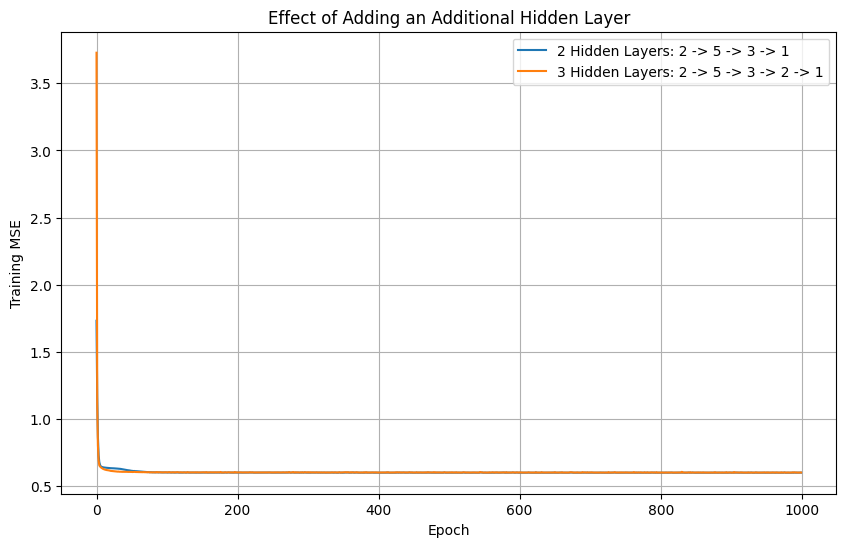

In [ ]:
# ============================================================
# BONUS 1: Additional Hidden Layer
# ============================================================
#
# Original:
#     2 -> 5 -> 3 -> 1
#
# Deeper model:
#     2 -> 5 -> 3 -> 2 -> 1
#
# We keep the optimizer, learning rate, epochs, initialization,
# and data the same for a fair comparison.
# ============================================================

hidden_layers_config_3_layers = [
    (5, "relu"),
    (3, "relu"),
    (2, "relu")
]

print("\n" + "=" * 60)
print("BONUS: 3-HIDDEN-LAYER NETWORK")
print("=" * 60)

nn_3_layers = NeuralNetwork(
    input_size=input_size,
    hidden_layers_config=hidden_layers_config_3_layers,
    output_size=output_size,
    seed=SEED
)

history_3_layers = train_adam(
    nn_3_layers,
    X_train,
    y_train,
    epochs=epochs,
    learning_rate=fixed_learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    batch_size=128,
    seed=SEED
)

y_pred_3_layers = nn_3_layers.predict(X_test)

mse_3_layers = mse_loss(
    y_test,
    y_pred_3_layers
)

print("\nTest MSE - 2 hidden layers:",
      mse)

print("Test MSE - 3 hidden layers:",
      mse_3_layers)

# Compare training curves
plt.figure(figsize=(10, 6))

plt.plot(
    optimizer_histories["adam"],
    label="2 Hidden Layers: 2 -> 5 -> 3 -> 1"
)

plt.plot(
    history_3_layers,
    label="3 Hidden Layers: 2 -> 5 -> 3 -> 2 -> 1"
)

plt.title("Effect of Adding an Additional Hidden Layer")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.legend()
plt.grid(True)
plt.show()


_Visualization generated by the preceding code cell._


### 5.2. Regularization (L2 Regularization / Weight Decay)


L2 Regularization | lambda = 0.001
Epoch    1/1000 | Regularized Loss = 1.744452 | MSE = 1.731243
Epoch  100/1000 | Regularized Loss = 0.610367 | MSE = 0.601974
Epoch  200/1000 | Regularized Loss = 0.608565 | MSE = 0.601220
Epoch  300/1000 | Regularized Loss = 0.607789 | MSE = 0.600602
Epoch  400/1000 | Regularized Loss = 0.607036 | MSE = 0.599944
Epoch  500/1000 | Regularized Loss = 0.607595 | MSE = 0.600617
Epoch  600/1000 | Regularized Loss = 0.606846 | MSE = 0.599930
Epoch  700/1000 | Regularized Loss = 0.607537 | MSE = 0.600693
Epoch  800/1000 | Regularized Loss = 0.606793 | MSE = 0.599964
Epoch  900/1000 | Regularized Loss = 0.607422 | MSE = 0.600596
Epoch 1000/1000 | Regularized Loss = 0.607444 | MSE = 0.600589

Test MSE with lambda=0.001: 0.622505

L2 Regularization | lambda = 0.01
Epoch    1/1000 | Regularized Loss = 1.859017 | MSE = 1.728929
Epoch  100/1000 | Regularized Loss = 0.658456 | MSE = 0.618116
Epoch  200/1000 | Regularized Loss = 0.655351 | MSE = 0.617037
Epoch  30

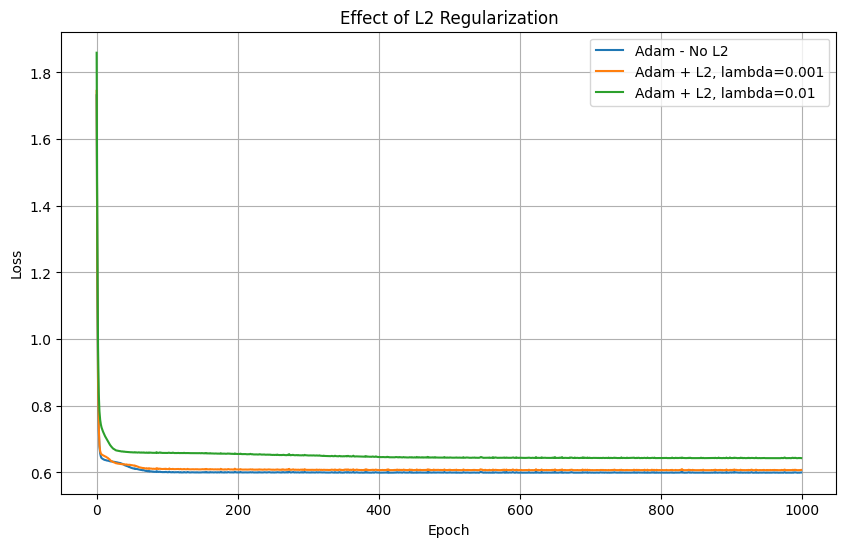

In [ ]:
# ============================================================
# BONUS 2: L2 Regularization / Weight Decay
# ============================================================
#
# L2-regularized objective:
#
#   Total Loss = MSE + lambda * sum(W^2)
#
# The corresponding weight gradient contains:
#
#   dL/dW = dMSE/dW + 2 * lambda * W
#
# Biases are not regularized here.
# ============================================================

def l2_penalty(model):
    """Sum of squared weights across all layers."""
    total = 0.0

    for layer in model.layers:
        total += np.sum(layer.weights ** 2)

    return total


def train_adam_l2(
    model,
    X,
    y,
    epochs,
    learning_rate=0.001,
    lambda_reg=0.001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    batch_size=128,
    gradient_clip_norm=5.0,
    seed=42
):
    """
    Adam + L2 regularization, implemented from scratch.
    """

    rng = np.random.default_rng(seed)
    state = create_optimizer_state(model)
    history = []

    n = X.shape[0]

    for epoch in range(1, epochs + 1):

        order = rng.permutation(n)

        for start in range(0, n, batch_size):

            batch_indices = order[start:start + batch_size]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            predictions = model.forward(X_batch)

            grad_output = mse_gradient(y_batch, predictions)
            model.backward(grad_output)

            # Add L2 gradient to weights.
            # We use the conventional 2*lambda*W derivative.
            for layer in model.layers:
                layer.grad_weights += (
                    2.0 * lambda_reg * layer.weights
                )

            if gradient_clip_norm is not None:
                clip_gradients(model, gradient_clip_norm)

            # Adam update
            for layer, layer_state in zip(model.layers, state):

                layer_state["m_w"] = (
                    beta1 * layer_state["m_w"]
                    + (1 - beta1) * layer.grad_weights
                )

                layer_state["m_b"] = (
                    beta1 * layer_state["m_b"]
                    + (1 - beta1) * layer.grad_biases
                )

                layer_state["s_w"] = (
                    beta2 * layer_state["s_w"]
                    + (1 - beta2) * layer.grad_weights ** 2
                )

                layer_state["s_b"] = (
                    beta2 * layer_state["s_b"]
                    + (1 - beta2) * layer.grad_biases ** 2
                )

                if "step" not in layer_state:
                    layer_state["step"] = 0

                layer_state["step"] += 1
                t = layer_state["step"]

                m_w_hat = layer_state["m_w"] / (1 - beta1 ** t)
                m_b_hat = layer_state["m_b"] / (1 - beta1 ** t)

                s_w_hat = layer_state["s_w"] / (1 - beta2 ** t)
                s_b_hat = layer_state["s_b"] / (1 - beta2 ** t)

                layer.weights -= (
                    learning_rate
                    * m_w_hat
                    / (np.sqrt(s_w_hat) + epsilon)
                )

                layer.biases -= (
                    learning_rate
                    * m_b_hat
                    / (np.sqrt(s_b_hat) + epsilon)
                )

        # Report total regularized objective
        full_predictions = model.forward(X)

        mse_value = mse_loss(y, full_predictions)
        regularized_loss = (
            mse_value
            + lambda_reg * l2_penalty(model)
        )

        history.append(regularized_loss)

        if epoch == 1 or epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"Regularized Loss = {regularized_loss:.6f} | "
                f"MSE = {mse_value:.6f}"
            )

    return history


lambda_regs = [0.001, 0.01]

regularization_histories = {}
regularization_models = {}
regularization_test_mse = {}

for lambda_reg_val in lambda_regs:

    print("\n" + "=" * 60)
    print(
        "L2 Regularization | "
        f"lambda = {lambda_reg_val}"
    )
    print("=" * 60)

    nn_reg = NeuralNetwork(
        input_size=input_size,
        hidden_layers_config=hidden_layers_config,
        output_size=output_size,
        seed=SEED
    )

    history_reg = train_adam_l2(
        nn_reg,
        X_train,
        y_train,
        epochs=epochs,
        learning_rate=fixed_learning_rate,
        lambda_reg=lambda_reg_val,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        batch_size=128,
        seed=SEED
    )

    regularization_histories[lambda_reg_val] = history_reg
    regularization_models[lambda_reg_val] = nn_reg

    y_pred_reg = nn_reg.predict(X_test)

    mse_reg = mse_loss(
        y_test,
        y_pred_reg
    )

    regularization_test_mse[lambda_reg_val] = mse_reg

    print(
        f"\nTest MSE with lambda={lambda_reg_val}: "
        f"{mse_reg:.6f}"
    )


# Plot regularized objective curves
plt.figure(figsize=(10, 6))

plt.plot(
    optimizer_histories["adam"],
    label="Adam - No L2"
)

for lambda_reg_val, history_reg in regularization_histories.items():
    plt.plot(
        history_reg,
        label=f"Adam + L2, lambda={lambda_reg_val}"
    )

plt.title("Effect of L2 Regularization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


_Visualization generated by the preceding code cell._


## 6. Summary and Analysis

### Impact of Learning Rates (Basic Gradient Descent)

### Interpretation

The two learning rates required by the task are compared using Basic Gradient Descent.

After running the notebook, compare:
- how quickly each curve decreases,
- the final training MSE after 1000 epochs,
- whether either learning rate is unstable,
- and whether a smaller learning rate needs more epochs to reach a similar loss.

Do not assume that 0.01 or 0.001 is automatically better; use the actual curves and final MSE values produced by the corrected implementation.


### Impact of Optimizers

### Interpretation

The notebook compares:
- Basic Gradient Descent,
- SGD with Momentum,
- Adam.

All three use the same baseline architecture and a learning rate of 0.001.

Use the plotted convergence curves and the test-set MSE table to determine:
1. which optimizer converges fastest,
2. which reaches the lowest training loss,
3. which gives the best test-set performance.

The conclusion should be based on the results generated when this notebook is executed, rather than hard-coded values.


### Impact of Additional Hidden Layers

### Interpretation

The required baseline architecture is:

`2 -> 5 -> 3 -> 1`

The bonus experiment adds another hidden layer:

`2 -> 5 -> 3 -> 2 -> 1`

Compare the test MSE of both models and their training-loss curves.

If the deeper model has a lower test MSE, it improved performance for this experiment. If its test MSE is higher, the extra layer did not improve generalization under the chosen training settings.


### Impact of L2 Regularization (Weight Decay)

### Interpretation

The L2 experiments use lambda values of 0.001 and 0.01.

Compare the regularized models with the unregularized Adam model using test MSE.

A lower test MSE indicates improved generalization for that particular lambda value. A higher test MSE can indicate that the regularization strength is too large or that the baseline model did not require additional regularization.

Again, use the actual values produced by the notebook rather than hard-coding a result.


### Conclusion

After running all experiments, summarize:

1. The effect of learning rate on Basic Gradient Descent.
2. The relative convergence of GD, Momentum, and Adam.
3. Which optimizer produced the best test-set MSE.
4. Whether adding an additional hidden layer improved performance.
5. Whether L2 regularization improved test-set performance.
6. The final performance of the selected model.

The final conclusion should be based on the numerical results and plots generated by this notebook.


## 7. From-Scratch Compliance Checklist

This implementation uses `sklearn.datasets.fetch_california_housing` **only to load the dataset required by the assignment**.

The following are implemented manually with NumPy:
- 80/20 train-test split
- Feature normalization
- Weight and bias initialization
- Dense layers
- ReLU activation and derivative
- Linear output activation
- Forward propagation
- Mean Squared Error
- Backpropagation
- Basic Gradient Descent
- SGD with Momentum
- Adam
- L2 regularization
- Prediction and test-set MSE

No `StandardScaler`, `train_test_split`, `MLPRegressor`, PyTorch, TensorFlow, Keras, or pre-built optimizer/model function is used for the neural-network implementation.